# Audio spectral Complexity and Entropy Analysis
## A Comparative Study Across Genres, Cultures, and Languages

**Name:** Om Chaudhari
**Roll No:** 230715
**Date:** April 2026  
**Project:** IDC606 Audio Analytics

---

### 1. Abstract / Introduction
This project explores the structural complexity of audio signals through the lens of **Normalized Hydrodynamic Entropy** and **Spectral Power Law** behavior. By analyzing frame-by-frame spectral energy distributions, we distinguish musical genres not just by their melody or rhythm, but by their inherent "stochasticity" and spectral signatures.

Key areas of exploration:
1. **Western Musical Genres**: Analyzing the GTZAN dataset.
2. **Cross-Cultural Musicality**: Comparing diverse musical traditions (Bollywood, Raga, etc.).
3. **Linguistic Complexity**: Investigating the entropy of spoken language across different tongues.
4. **Self-Similarity**: Evaluating $1/f^\beta$ power-law behavior in spectral density.

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Suppress librosa/scipy warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Set Visual Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

### 2. Methodology: Normalized Hydrodynamic Entropy

The core metric used in this study is the **Normalized Hydrodynamic Entropy**. Unlike standard Shannon entropy applied to a steady-state signal, this approach treats the spectral energy within STFT frames as a probability distribution.

#### Mathematical Definition:
1. **STFT**: Compute the Short-Time Fourier Transform.
2. **Modal Energy**: $E(k)$ is the squared magnitude of frequency bins.
3. **Probability Calculation**: $p_k = E_k / \sum E_k$.
4. **Entropy**: $S_H = -\sum p_k \log_2 p_k$.
5. **Normalization**: $S_{norm} = S_H / \log_2 M$, where $M$ is the number of frequency bins.

In [ ]:
def calculate_normalized_hydrodynamic_entropy(audio_path, frame_size=1024, hop_length=512):
    """
    Computes frame-by-frame normalized entropy for an audio file.
    """
    try:
        y, sr = librosa.load(audio_path, sr=None, mono=True, duration=30)
        S = librosa.stft(y, n_fft=frame_size, hop_length=hop_length)
        energy_spectrum = np.abs(S) ** 2

        # Add epsilon to avoid division by zero
        total_energy = np.sum(energy_spectrum, axis=0, keepdims=True)
        probs = energy_spectrum / (total_energy + 1e-10)

        # Entropy calculation
        log_probs = np.zeros_like(probs)
        mask = probs > 0
        log_probs[mask] = np.log2(probs[mask])

        raw_entropy = -np.sum(probs * log_probs, axis=0)
        max_entropy = np.log2(energy_spectrum.shape[0])

        return raw_entropy / max_entropy, S, sr
    except Exception as e:
        return None, None, None

### 3. Data Loading & Preprocessing

We load the pre-calculated features generated during the experimental phase. This includes Western genres, cross-cultural styles, and linguistic datasets.

In [ ]:
# Paths to precomputed datasets
DATA_DIR = "c:/Users/omcc/ml_env/idc606"
genre_path = os.path.join(DATA_DIR, "genre_entropy_analysis.csv")
cultural_path = os.path.join(DATA_DIR, "Normalized_Dataset", "entropy_features.csv")
lang_path = os.path.join(DATA_DIR, "entropy_analysis_results.csv")
spectra_path = os.path.join(DATA_DIR, "spectra_data.csv")
meta_path = os.path.join(DATA_DIR, "spectra_metadata.csv")

# Load Western Genres Data
if os.path.exists(genre_path):
    df_genre = pd.read_csv(genre_path)
    print(f"Loaded {len(df_genre)} tracks from Western Genres dataset.")
else:
    df_genre = None

# Load Cross-Cultural Data
if os.path.exists(cultural_path):
    df_cultural = pd.read_csv(cultural_path)
    print(f"Loaded {len(df_cultural)} tracks from Cross-Cultural dataset.")
else:
    df_cultural = None

# Load Language/Linguistic Data
if os.path.exists(lang_path):
    df_lang = pd.read_csv(lang_path)
    print(f"Loaded {len(df_lang)} tracks from Linguistic/General dataset.")
else:
    df_lang = None

# Load Spectral Data
if os.path.exists(spectra_path) and os.path.exists(meta_path):
    df_spec = pd.read_csv(spectra_path)
    df_spec_meta = pd.read_csv(meta_path)
else:
    df_spec = None
    df_spec_meta = None

Loaded 1000 tracks from Western Genres dataset.
Loaded 4992 tracks from Cross-Cultural dataset.
Loaded 2812 tracks from Linguistic/General dataset.


### 4. Comparative Spectral Analysis

To visualize how entropy reflects musical structure, we compare a standard spectrogram with the temporal entropy curve. High entropy indicates 'white noise-like' spectral spread (disharmony or complexity), while low entropy indicates concentrated spectral peaks (ordered tones).

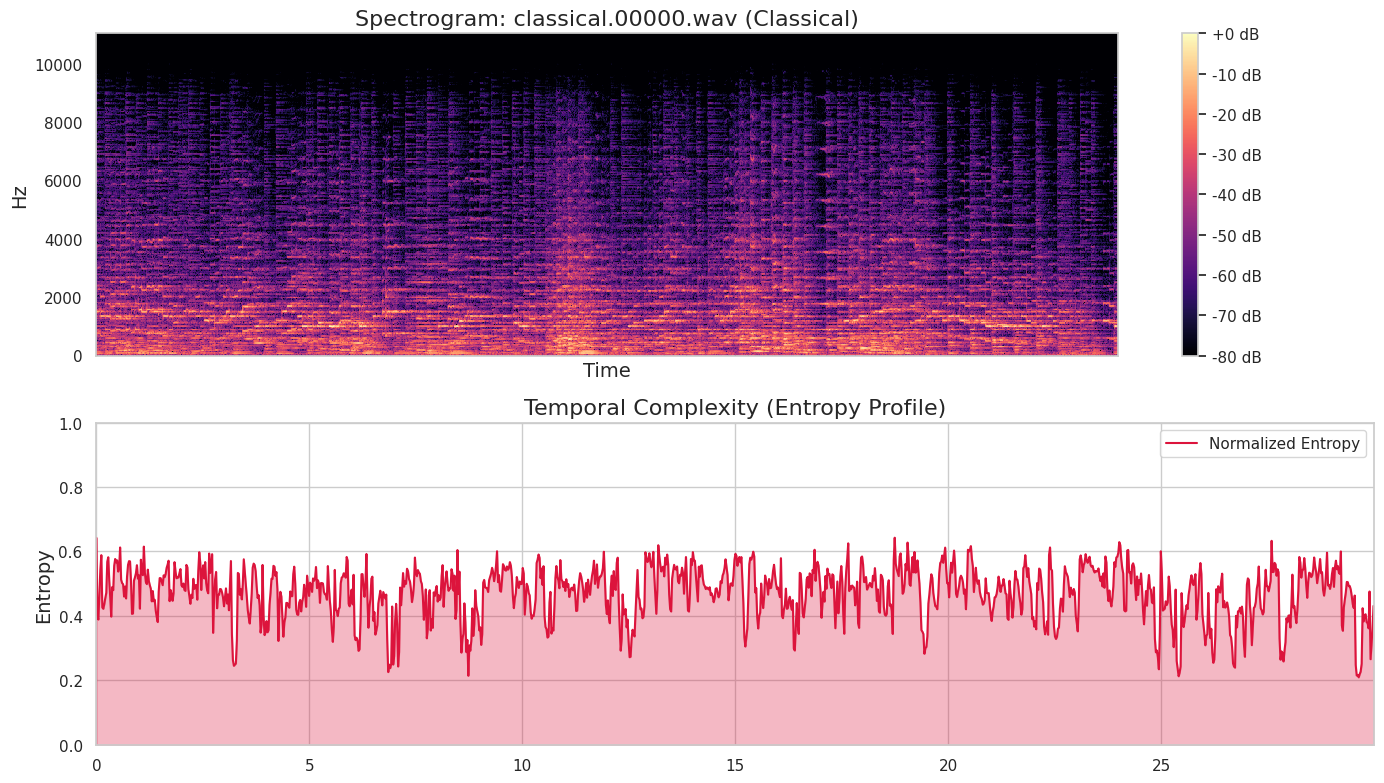

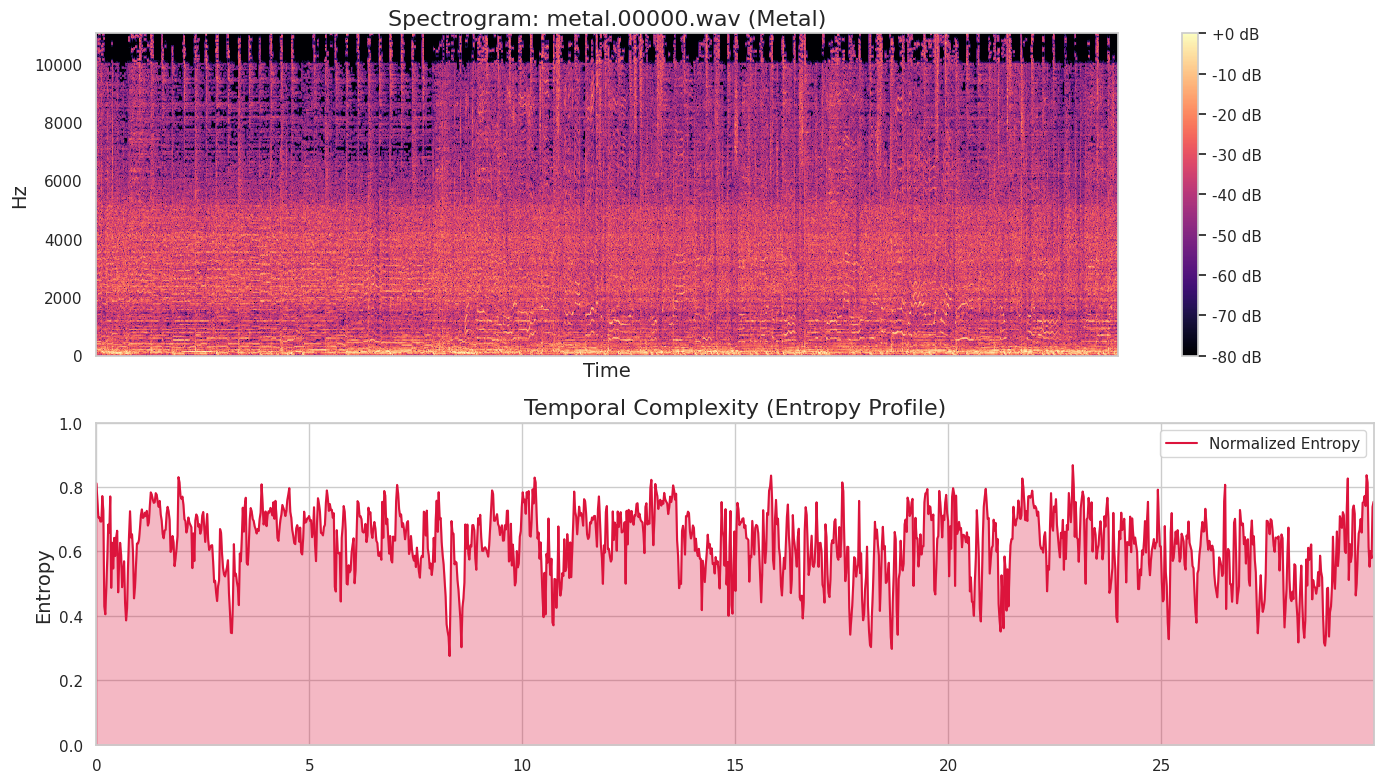

In [ ]:
def plot_comparative_analysis(genre="blues", song_index=0):
    base_dir = os.path.join(DATA_DIR, "Genre_With_Song/genres_original", genre)
    if not os.path.exists(base_dir):
        return

    files = [f for f in os.listdir(base_dir) if f.endswith('.wav')]
    if not files: return

    file_path = os.path.join(base_dir, files[song_index])
    entropy, S, sr = calculate_normalized_hydrodynamic_entropy(file_path)

    if entropy is not None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

        # Spectrogram
        S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax1, cmap='magma')
        ax1.set_title(f"Spectrogram: {files[song_index]} ({genre.capitalize()})")
        plt.colorbar(img, ax=ax1, format="%+2.0f dB")

        # Entropy
        times = librosa.times_like(entropy, sr=sr, hop_length=512)
        ax2.plot(times, entropy, color='crimson', label='Normalized Entropy')
        ax2.fill_between(times, entropy, color='crimson', alpha=0.3)
        ax2.set_ylim(0, 1)
        ax2.set_ylabel("Entropy")
        ax2.set_title("Temporal Complexity (Entropy Profile)")
        ax2.legend()
        plt.tight_layout()
        plt.show()

# Visualize a few samples
if os.path.exists(os.path.join(DATA_DIR, "Genre_With_Song/genres_original")):
    for g in ["classical", "metal"]:
        plot_comparative_analysis(g, 0)

### 5. Western Genre Entropy Distributions

Hierarchical analysis of the Western music dataset shows distinct complexity tiers.

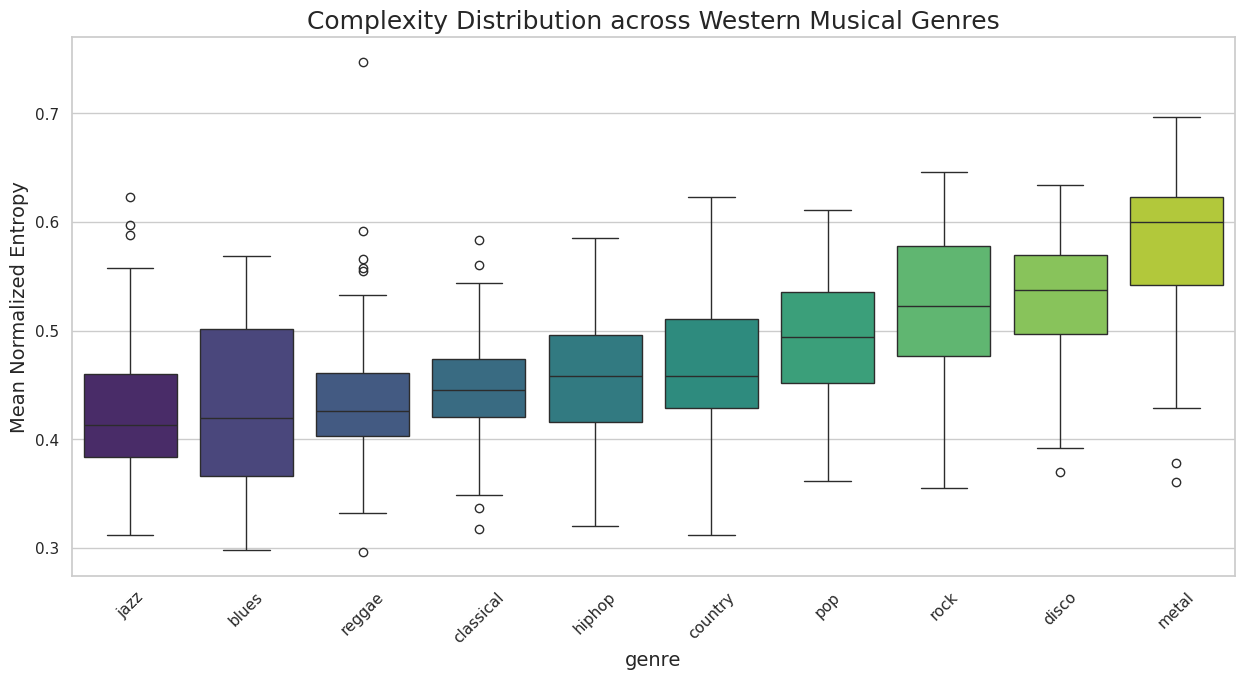

In [ ]:
if df_genre is not None:
    plt.figure(figsize=(15, 7))
    order = df_genre.groupby("genre")["entropy_mean"].mean().sort_values().index
    sns.boxplot(data=df_genre, x="genre", y="entropy_mean", order=order, palette="viridis")
    plt.title("Complexity Distribution across Western Musical Genres", fontsize=18)
    plt.ylabel("Mean Normalized Entropy")
    plt.xticks(rotation=45)
    plt.show()

### 6. Variability and Information Stability

We assess the stability of information content (standard deviation of entropy) versus its mean level.

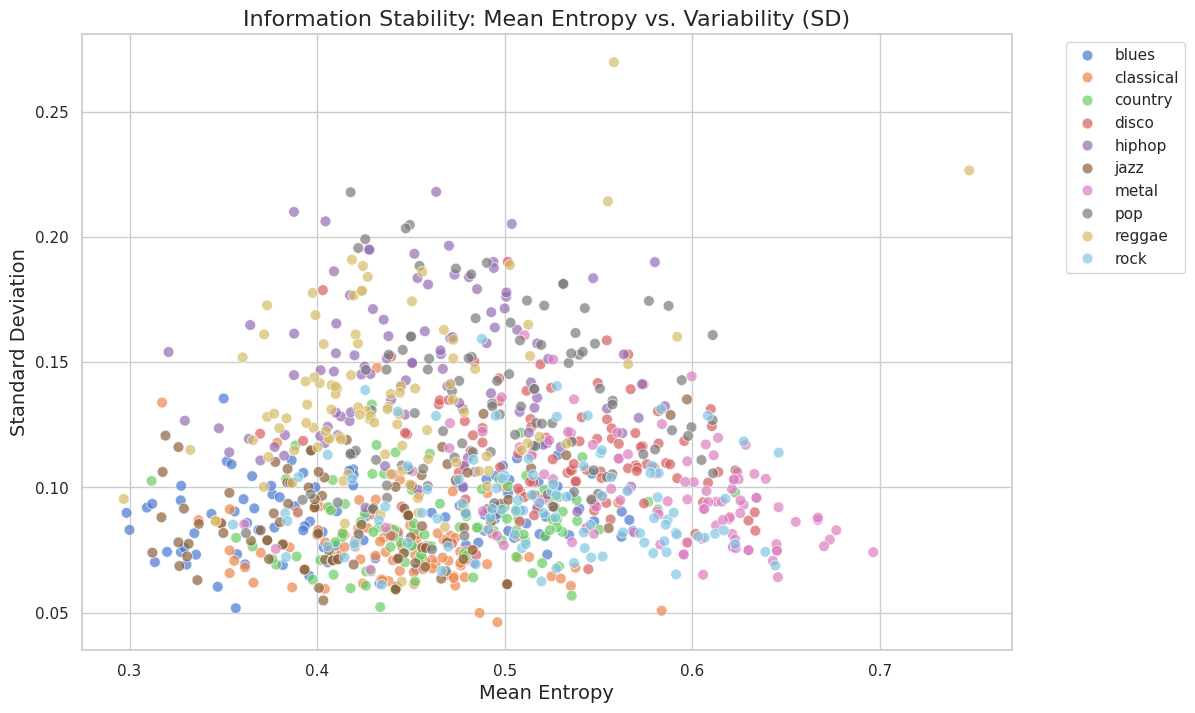

In [ ]:
if df_genre is not None:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_genre, x="entropy_mean", y="entropy_sd", hue="genre", alpha=0.7, s=60)
    plt.title("Information Stability: Mean Entropy vs. Variability (SD)")
    plt.xlabel("Mean Entropy")
    plt.ylabel("Standard Deviation")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

### 7. Spectral Power Law (1/f) Analysis

Many natural systems, including music, exhibit a power-law distribution ($E(k) \propto k^{-\beta}$).

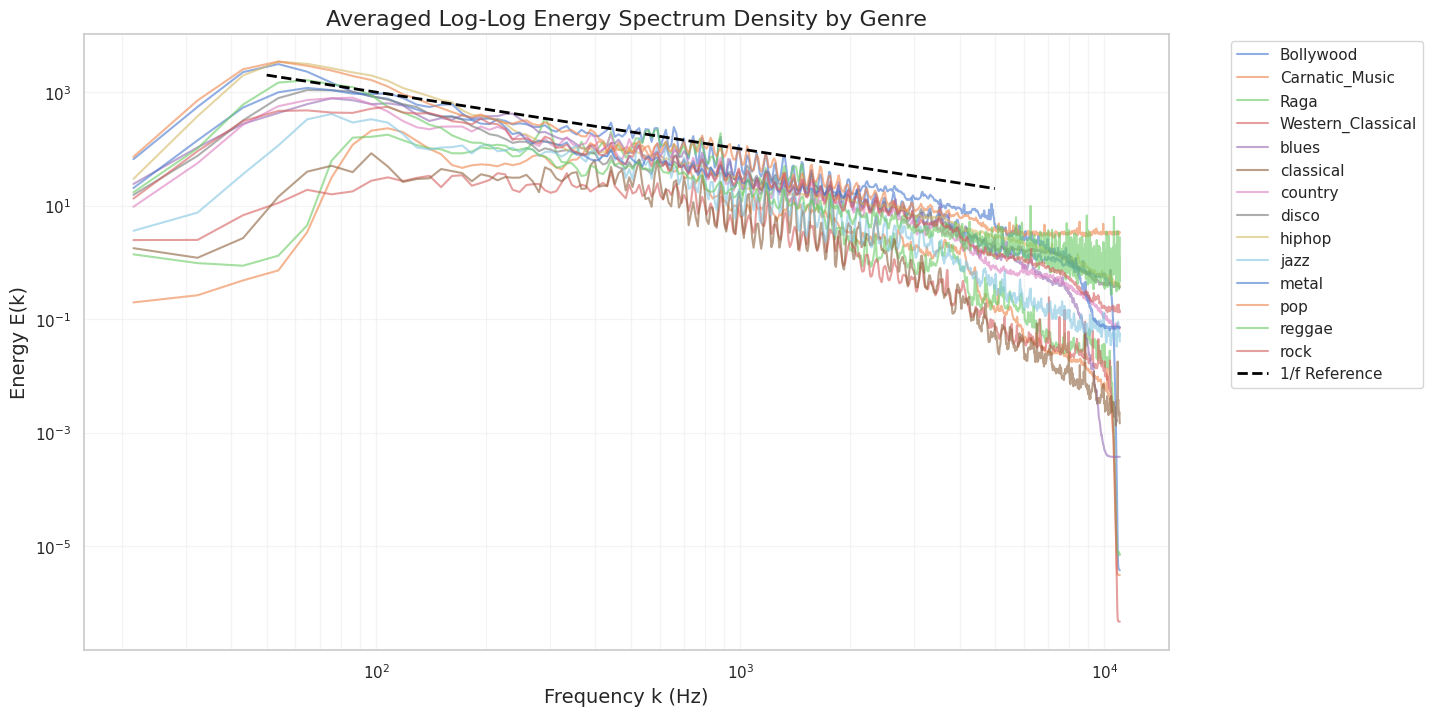

In [ ]:
if df_spec is not None:
    plt.figure(figsize=(14, 8))
    for genre in df_spec['Genre'].unique():
        subset = df_spec[df_spec['Genre'] == genre]
        plt.loglog(subset['Frequency'], subset['Energy'], label=genre, alpha=0.6)

    f_ref = np.linspace(50, 5000, 100)
    e_ref = 1e5 / f_ref
    plt.loglog(f_ref, e_ref, '--', color='black', label="1/f Reference", linewidth=2)

    plt.title("Averaged Log-Log Energy Spectrum Density by Genre")
    plt.xlabel("Frequency k (Hz)")
    plt.ylabel("Energy E(k)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

### 8. Cross-Cultural Analysis: Diverse Musical Traditions

Expanding the analysis to non-Western styles (e.g., Bollywood, Carnatic, Raga) reveals how different cultural aesthetics manifest as spectral complexity.

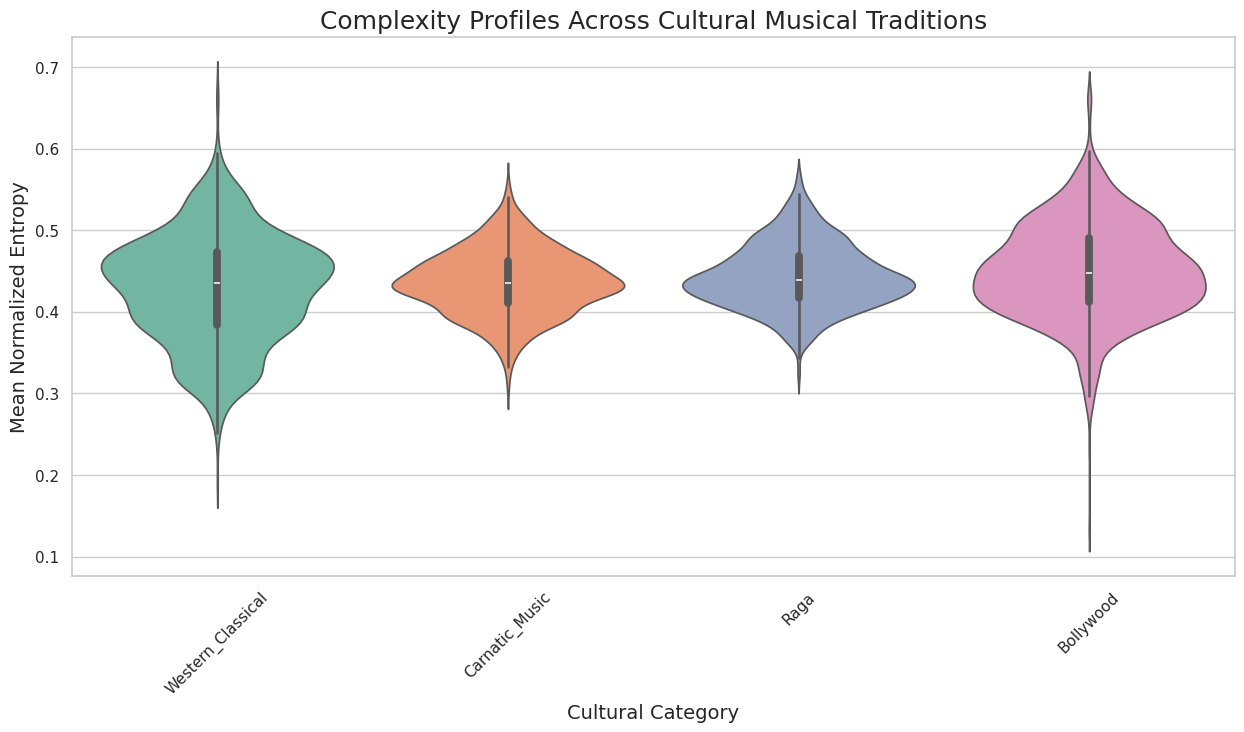

In [ ]:
if df_cultural is not None:
    plt.figure(figsize=(15, 7))
    # 'Category' is the column for styles, 'Mean_Normalized_Entropy' is the value
    order = df_cultural.groupby("Category")["Mean_Normalized_Entropy"].mean().sort_values().index

    # Use a violin plot for density visualization
    sns.violinplot(data=df_cultural, x="Category", y="Mean_Normalized_Entropy", order=order, palette="Set2")
    plt.title("Complexity Profiles Across Cultural Musical Traditions", fontsize=18)
    plt.ylabel("Mean Normalized Entropy")
    plt.xlabel("Cultural Category")
    plt.xticks(rotation=45)
    plt.show()

### 9. Linguistic Entropy: The Complexity of Speech

Finally, we examine the entropy profiles of different spoken languages to compare the complexity of vocal communication with musical expression.

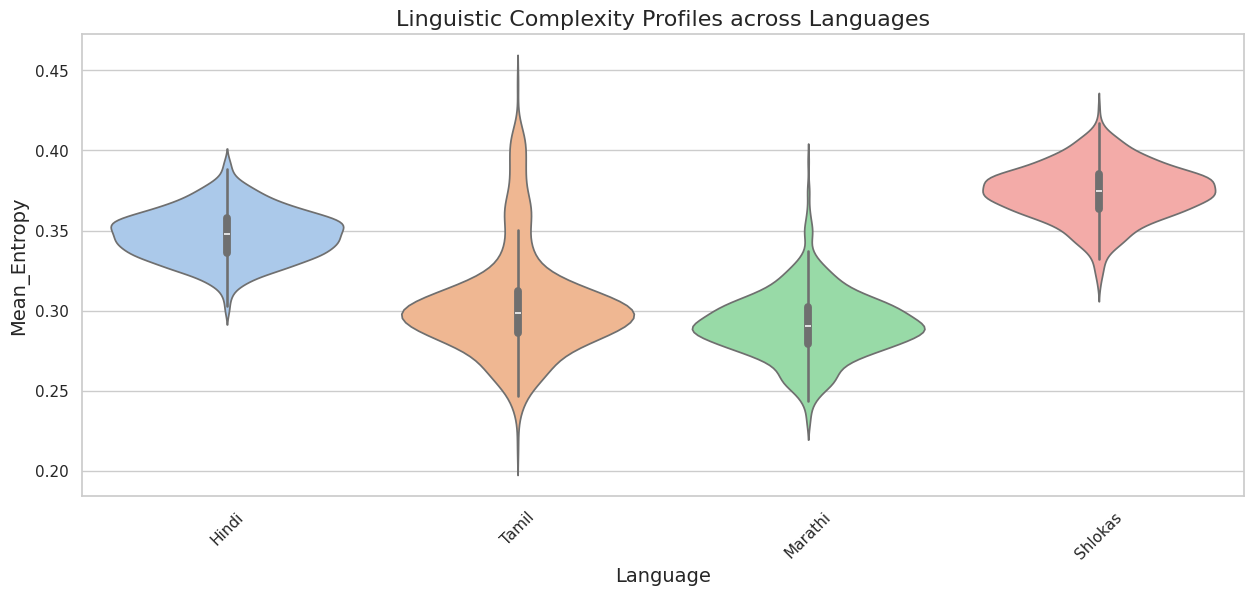

In [ ]:
if df_lang is not None:
    plt.figure(figsize=(15, 6))
    col = "Language" if "Language" in df_lang.columns else "genre"
    val = "Mean_Entropy" if "Mean_Entropy" in df_lang.columns else "entropy_mean"

    sns.violinplot(data=df_lang, x=col, y=val, palette="pastel")
    plt.title("Linguistic Complexity Profiles across Languages")
    plt.xticks(rotation=45)
    plt.show()

### 10. Conclusion: The "Grand Collage" of Evidence

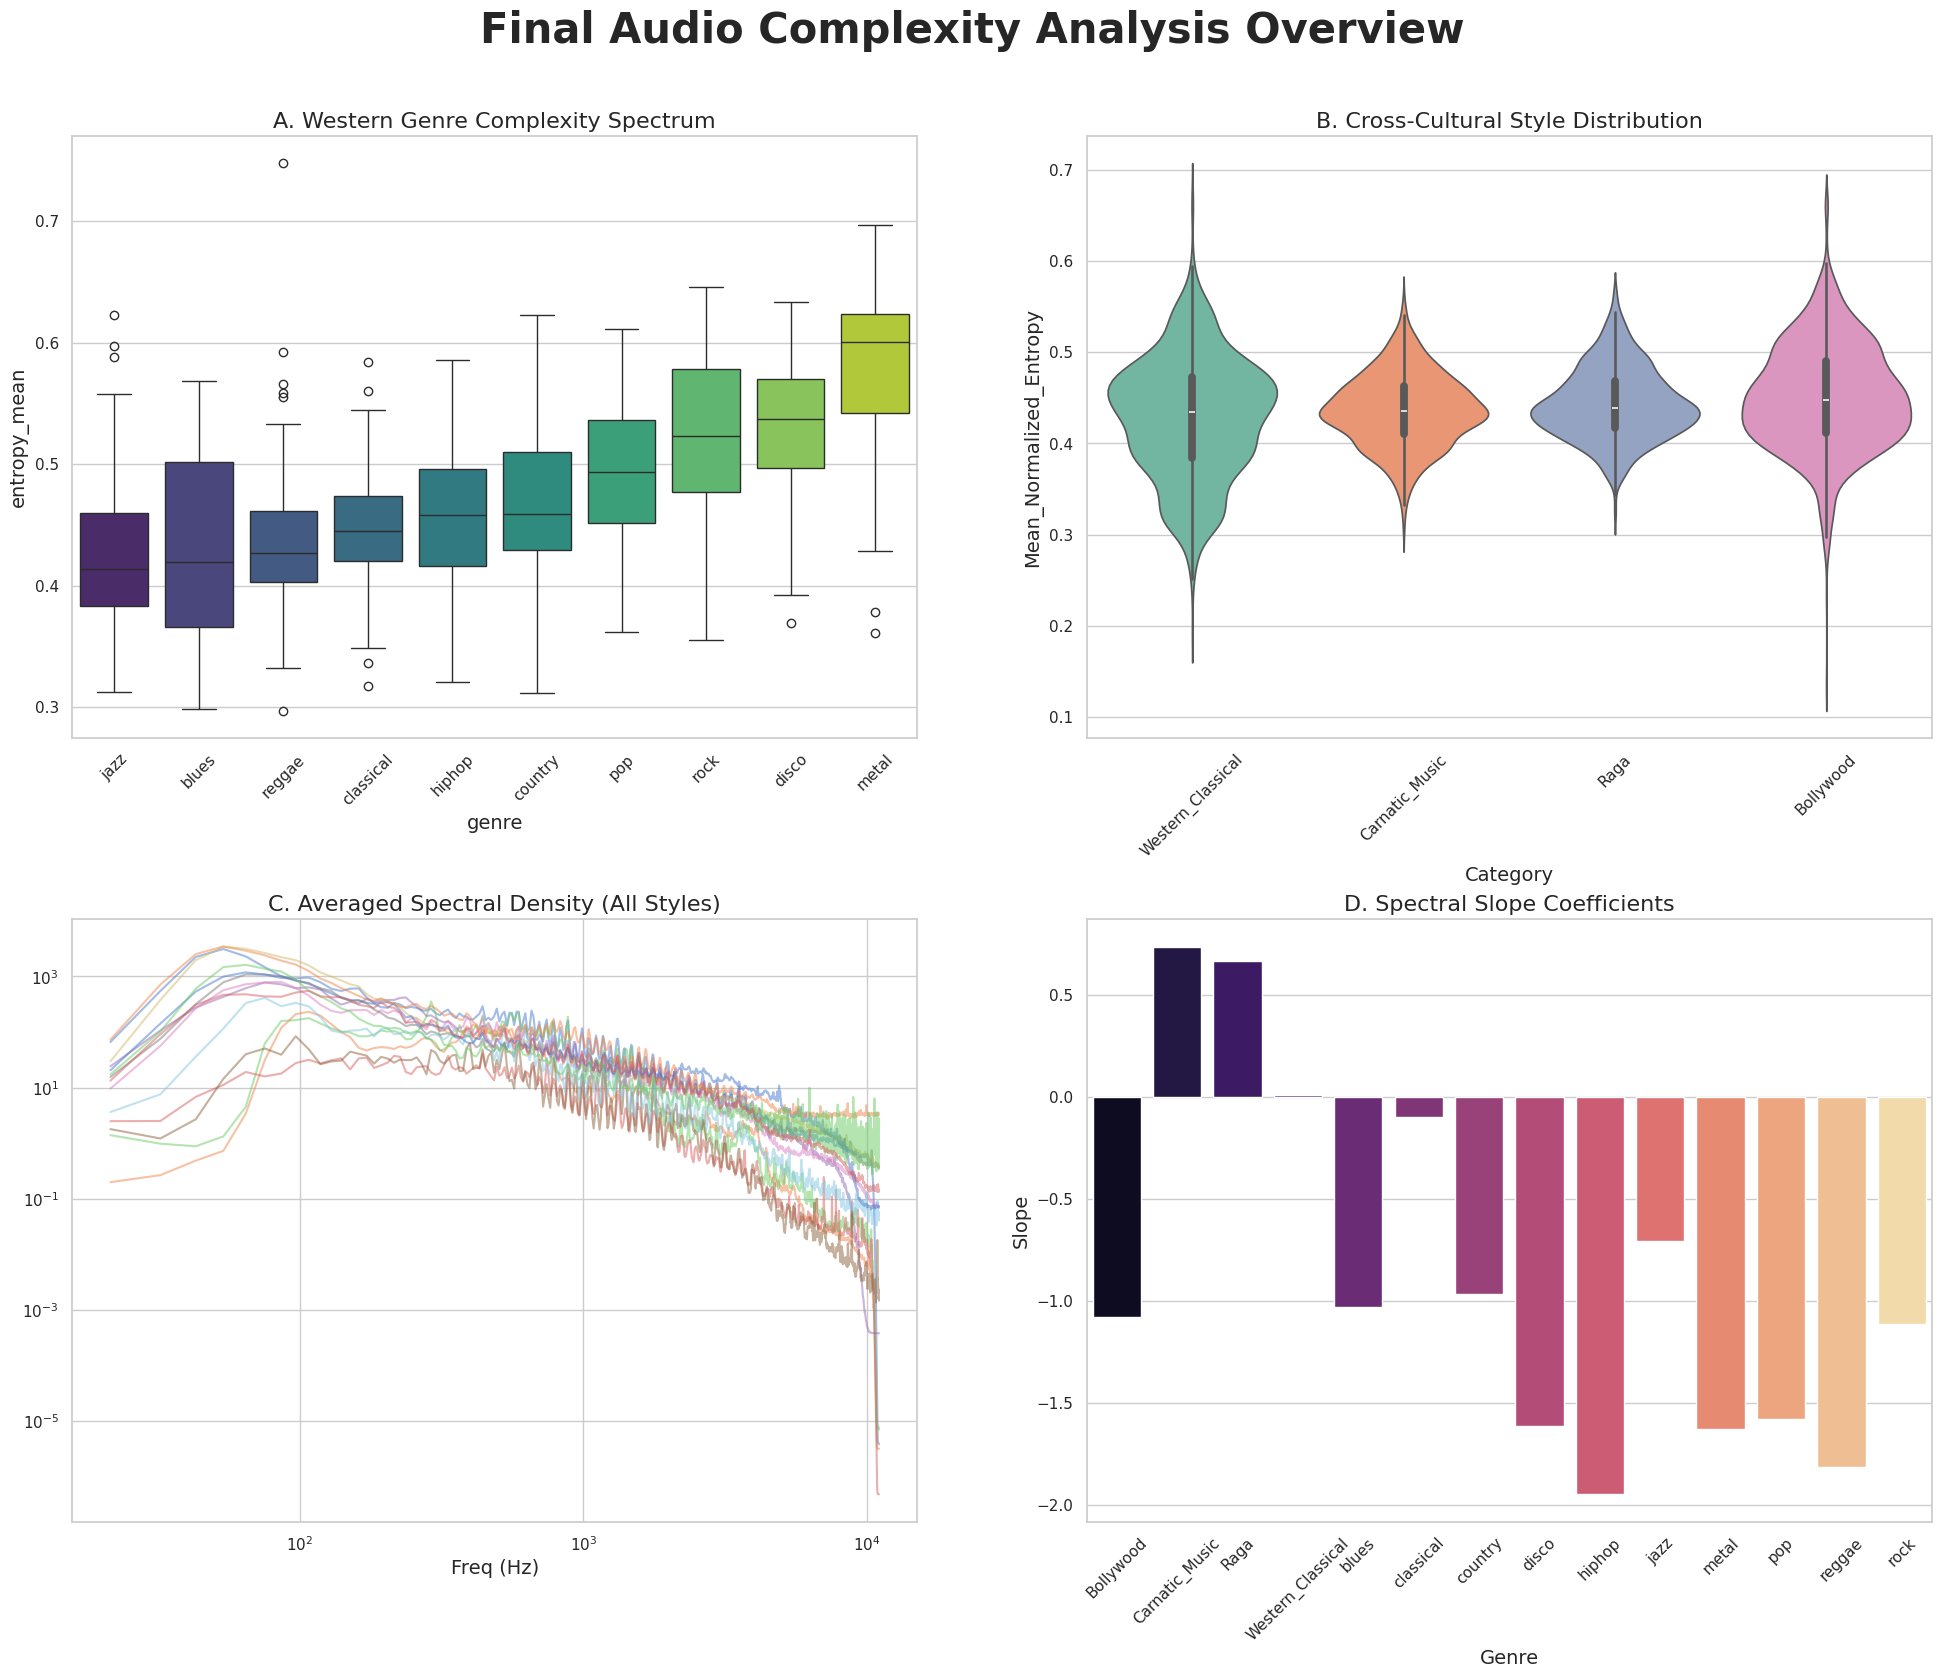

In [ ]:
def create_grand_collage():
    if df_genre is None or df_spec is None: return

    fig = plt.figure(figsize=(24, 18))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

    # Panel 1: Genre Distribution
    ax1 = fig.add_subplot(gs[0, 0])
    order = df_genre.groupby("genre")["entropy_mean"].mean().sort_values().index
    sns.boxplot(data=df_genre, x="genre", y="entropy_mean", order=order, palette="viridis", ax=ax1)
    ax1.set_title("A. Western Genre Complexity Spectrum")
    ax1.tick_params(axis='x', rotation=45)

    # Panel 2: Cultural Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    if df_cultural is not None:
        order_c = df_cultural.groupby("Category")["Mean_Normalized_Entropy"].mean().sort_values().index
        sns.violinplot(data=df_cultural, x="Category", y="Mean_Normalized_Entropy", order=order_c, palette="Set2", ax=ax2)
        ax2.set_title("B. Cross-Cultural Style Distribution")
        ax2.tick_params(axis='x', rotation=45)

    # Panel 3: Spectral Power Density
    ax3 = fig.add_subplot(gs[1, 0])
    for g in df_spec['Genre'].unique():
        subset = df_spec[df_spec['Genre'] == g]
        ax3.loglog(subset['Frequency'], subset['Energy'], alpha=0.5)
    ax3.set_title("C. Averaged Spectral Density (All Styles)")
    ax3.set_xlabel("Freq (Hz)")

    # Panel 4: Slopes Summary
    ax4 = fig.add_subplot(gs[1, 1])
    if df_spec_meta is not None:
        sns.barplot(data=df_spec_meta, x="Genre", y="Slope", palette="magma", ax=ax4)
        ax4.set_title("D. Spectral Slope Coefficients")
        ax4.tick_params(axis='x', rotation=45)

    fig.suptitle("Final Audio Complexity Analysis Overview", fontsize=30, fontweight='bold', y=0.95)
    plt.savefig("Grand_Submission_Collage_Full.png", dpi=300, bbox_inches='tight')
    plt.show()

create_grand_collage()